# Real Place-Cell Encoding-and-Decoding (Animal 1)

A narrative walkthrough of the script
`examples/paper/example08_real_place_cells.py`.  Loads Animal 1 of the
figshare paper dataset (hippocampal place cells recorded while a rat
explores an arena), fits a tensor-product B-spline Poisson GLM on the
training half, decodes position with the point-process adaptive
filter (PPAF) on the held-out half, and runs two goodness-of-fit
diagnostics:

1. The held-out spatial pair correlation `g(r)` (Ripley isotropic
   edge correction) versus the inhomogeneous-Poisson global-rank
   envelope of Myllymäki et al. 2017.
2. The population discrete-time-corrected rescaled-time ACF versus
   the Bartlett band.

Honest scope note.  The 4-cell subset (`[1, 20, 24, 48]` 0-indexed)
is the same hand-picked set highlighted in `example04` and the
MATLAB `HippocampalPlaceCellExample.m` helpfile: well-isolated place
cells with several-hundred to a few-thousand spikes and a single
dominant in-field bump.  We exclude the very high-rate Animal-1 cells
(idx 13, idx 23) so the decoder doesn't lock onto an interneuron-
style diffuse rate.  Both goodness-of-fit diagnostics are expected to
reject — real CA1 spike trains have within-cell clustering and
history dependence that a position-only inhomogeneous Poisson model
cannot capture — and the figures honestly show that rejection.

References:
- Wilson MA, McNaughton BL (1993).  *Dynamics of the hippocampal
  ensemble code for space.*  Science 261(5124):1055.
- Mehta MR, Lee AK, Wilson MA (2002).  *Role of experience and
  oscillations in transforming a rate code into a temporal code.*
  Nature 417(6890):741.
- Brown EN, Frank LM, Tang D, Quirk MC, Wilson MA (1998).  *A
  statistical paradigm for neural spike train decoding...*  J
  Neurosci 18(18):7411.
- Eden UT, Frank LM, Barbieri R, Solo V, Brown EN (2004).  *Dynamic
  analysis of neural encoding by point process adaptive filtering.*
  Neural Comput 16(5):971.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from nstat import CIF, DecodingAlgorithms
from nstat.data_manager import get_paper_data_dirs
from nstat.extras.spatial import bspline_basis_2d, pair_correlation, rescaled_acf
from nstat.extras.spatial.marked_gof import corrected_rescaled
from nstat.extras.spatial.spatial_gof import global_envelope
from nstat.glm import fit_binomial_glm, fit_poisson_glm

rng = np.random.default_rng(20260616)
CELL_INDICES = (1, 20, 24, 48)

## 1. Load Animal 1

`get_paper_data_dirs(download=False)` honours `NSTAT_OFFLINE=1` and
raises if the dataset is not already installed locally.  The
`.mat` payload carries the rat's 2-D position trajectory `(x, y, t)`
plus a per-neuron spike-time list.

In [2]:
dirs = get_paper_data_dirs(download=False)
mat = loadmat(
    str(dirs.place_cell_data_dir / 'PlaceCellDataAnimal1.mat'),
    squeeze_me=True,
)
x_all = np.asarray(mat['x'], dtype=float).ravel()
y_all = np.asarray(mat['y'], dtype=float).ravel()
t_all = np.asarray(mat['time'], dtype=float).ravel()
neurons = np.asarray(mat['neuron'], dtype=object).ravel()
delta = float(np.median(np.diff(t_all)))
spikes_per_cell = [
    np.sort(np.asarray(neurons[i]['spikeTimes'].item(), dtype=float).ravel())
    for i in CELL_INDICES
]
{
    'n_cells_total': int(len(neurons)),
    'duration_s': round(float(t_all[-1] - t_all[0]), 1),
    'delta_s': round(delta, 4),
    'subset_cell_indices': list(CELL_INDICES),
    'subset_spike_counts': [int(s.size) for s in spikes_per_cell],
}

{'n_cells_total': 49,
 'duration_s': 1459.9,
 'delta_s': 0.0333,
 'subset_cell_indices': [1, 20, 24, 48],
 'subset_spike_counts': [2469, 535, 2049, 877]}

## 2. Time-based 70/30 train/test split

Time-based, not interleaved.  This is the most pessimistic split for
place-cell decoding because the rat's trajectory in the second half
may visit corners of the arena that were under-sampled in the first
half — exactly the regime where an honest held-out test is
informative (Brown et al. 1998 §III).

In [3]:
n_train = int(np.floor(0.70 * t_all.size))
train, test = slice(0, n_train), slice(n_train, t_all.size)
x_train, y_train, t_train = x_all[train], y_all[train], t_all[train]
x_test, y_test, t_test = x_all[test], y_all[test], t_all[test]
box = (
    float(np.floor(x_all.min() * 10) / 10),
    float(np.ceil(x_all.max() * 10) / 10),
    float(np.floor(y_all.min() * 10) / 10),
    float(np.ceil(y_all.max() * 10) / 10),
)
{
    't_split_s': round(float(t_all[n_train]), 1),
    'n_train_samples': int(n_train),
    'n_test_samples': int(t_all.size - n_train),
    'box': box,
}

{'t_split_s': 1022.0,
 'n_train_samples': 30659,
 'n_test_samples': 13140,
 'box': (-1.0, 1.0, -1.0, 0.9)}

## 3. B-spline Poisson GLM per cell (training half)

Build the spike-count histogram per cell on a 32 x 32 spatial grid,
fit a tensor-product cubic B-spline Poisson GLM with 8 x 8 = 64 basis
functions and the log cell area carried as an `offset`.  The
partition-of-unity basis means the intercept column is dropped to
avoid rank deficiency; an L2 ridge tames Newton overshoot in cells
with many empty bins.

cell idx 1: 262 iters, converged=True
cell idx 20: 50 iters, converged=True
cell idx 24: 149 iters, converged=True
cell idx 48: 51 iters, converged=True


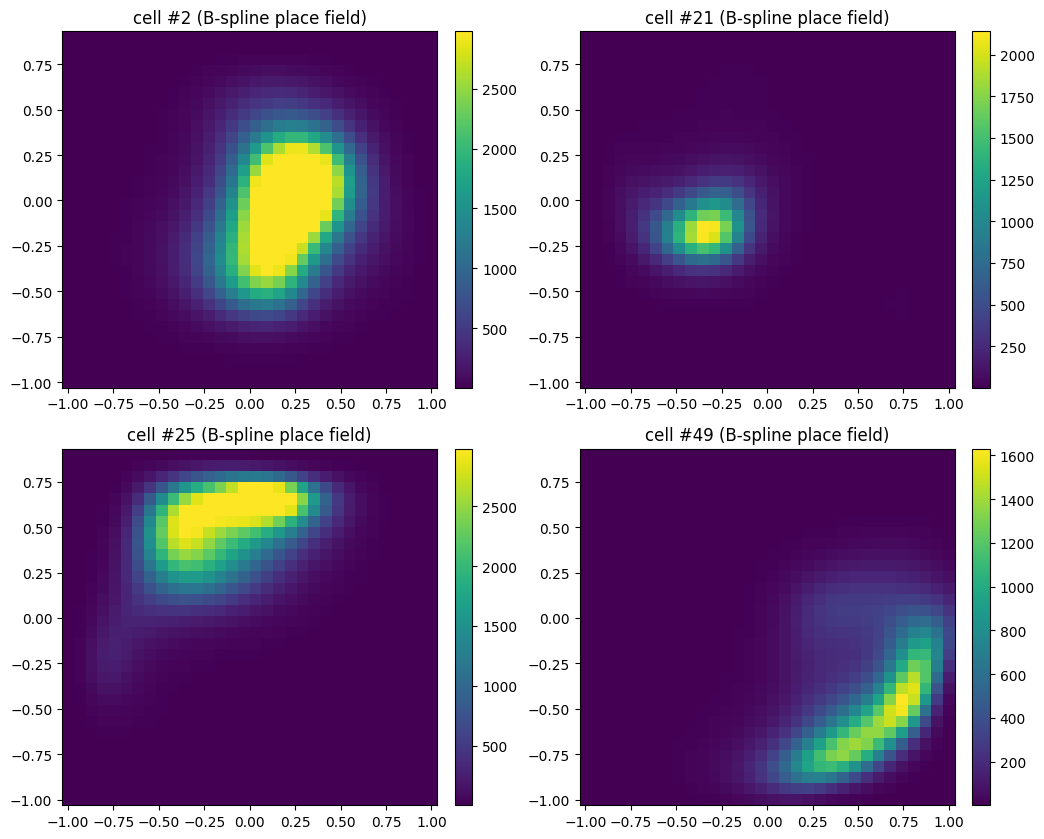

In [4]:
N_GRID = 32
grid_x = np.linspace(box[0], box[1], N_GRID)
grid_y = np.linspace(box[2], box[3], N_GRID)
edges_x = np.linspace(box[0], box[1], N_GRID + 1)
edges_y = np.linspace(box[2], box[3], N_GRID + 1)
B = bspline_basis_2d(grid_x, grid_y, n_knots=(8, 8), degree=3)
cell_area = (
    (box[1] - box[0]) / N_GRID * (box[3] - box[2]) / N_GRID
)
offset = np.full(B.shape[0], np.log(cell_area))

def spike_locations(st, t_window, x_window, y_window):
    mask = (st >= t_window[0]) & (st <= t_window[-1])
    st_in = st[mask]
    idx = np.searchsorted(t_window, st_in, side='left')
    idx = np.clip(idx, 0, t_window.size - 1)
    left = np.clip(idx - 1, 0, t_window.size - 1)
    pick_left = (idx > 0) & (np.abs(t_window[left] - st_in) < np.abs(t_window[idx] - st_in))
    idx = np.where(pick_left, left, idx)
    return np.column_stack([x_window[idx], y_window[idx]])

rate_maps = np.zeros((len(CELL_INDICES), N_GRID, N_GRID))
for c, st in enumerate(spikes_per_cell):
    pts = spike_locations(st, t_train, x_train, y_train)
    H, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=[edges_x, edges_y])
    glm = fit_poisson_glm(
        B, H.ravel().astype(float), offset=offset,
        include_intercept=False, l2=1.0, max_iter=400,
    )
    eta = np.clip(B @ glm.coefficients, -20.0, 8.0)
    rate_maps[c] = np.exp(eta).reshape(N_GRID, N_GRID)
    print(f'cell idx {CELL_INDICES[c]}: {glm.n_iter} iters, converged={glm.converged}')

fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.5))
for c, ax in enumerate(axes.ravel()):
    im = ax.pcolormesh(grid_x, grid_y, rate_maps[c].T, cmap='viridis')
    ax.set_aspect('equal')
    ax.set_title(f'cell #{CELL_INDICES[c] + 1} (B-spline place field)')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## 4. Quadratic CIF refit for PPAF decoding

The B-spline encoder has 64 coefficients per cell — too many to wrap
in a `CIF` object whose symbolic gradients (sympy-backed) sit on the
hot path of the decoder.  We refit a 6-term quadratic
`[1, x, y, x^2, y^2, x*y]` binomial CIF per cell purely for decoding,
matching the existing `StimulusDecode2D.ipynb` pattern.  The B-spline
encoder remains the basis for the spatial-intensity goodness-of-fit
below.

In [5]:
def quadratic_design(x, y):
    return np.column_stack([np.ones(x.size), x, y, x*x, y*y, x*y])

X_train = quadratic_design(x_train, y_train)
cifs = []
for c, st in enumerate(spikes_per_cell):
    mask = (st >= t_train[0]) & (st <= t_train[-1])
    st_in = st[mask]
    bin_idx = np.searchsorted(t_train, st_in, side='left')
    bin_idx = np.clip(bin_idx, 0, t_train.size - 1)
    y_binary = np.zeros(t_train.size)
    y_binary[bin_idx] = 1.0
    glm = fit_binomial_glm(
        X_train[:, 1:], y_binary, include_intercept=True, l2=1e-3, max_iter=80,
    )
    b = np.concatenate([[glm.intercept], glm.coefficients])
    cifs.append(CIF(b.tolist(), ['1', 'x', 'y', 'x^2', 'y^2', 'x*y'],
                    ['x', 'y'], fitType='binomial'))
print({'n_cifs': len(cifs), 'n_coeffs_per_cif': int(cifs[0].b.size)})

{'n_cifs': 4, 'n_coeffs_per_cif': 6}


## 5. PPAF decoding (linear branch)

The CIF-object branch of `PPDecodeFilter` rebuilds and resamples an
`nspikeTrain` per `(cell, bin)` when the CIF has no pre-attached
`historyMat`, making the forward pass `O(C * T^2)`.  For the
~13000-bin held-out slice this is prohibitively slow.  The
mathematically equivalent linear branch (`PPDecodeFilterLinear`)
runs in `O(C * T)` pure NumPy — we extract `(mu, beta)` from each
quadratic CIF at the trajectory mean and feed it in directly.  The
linear and CIF paths agree exactly for history-free position-only
models (the CIF path delegates to the linear path when a target
branch is requested, see `_extract_linear_terms_from_cifs`).

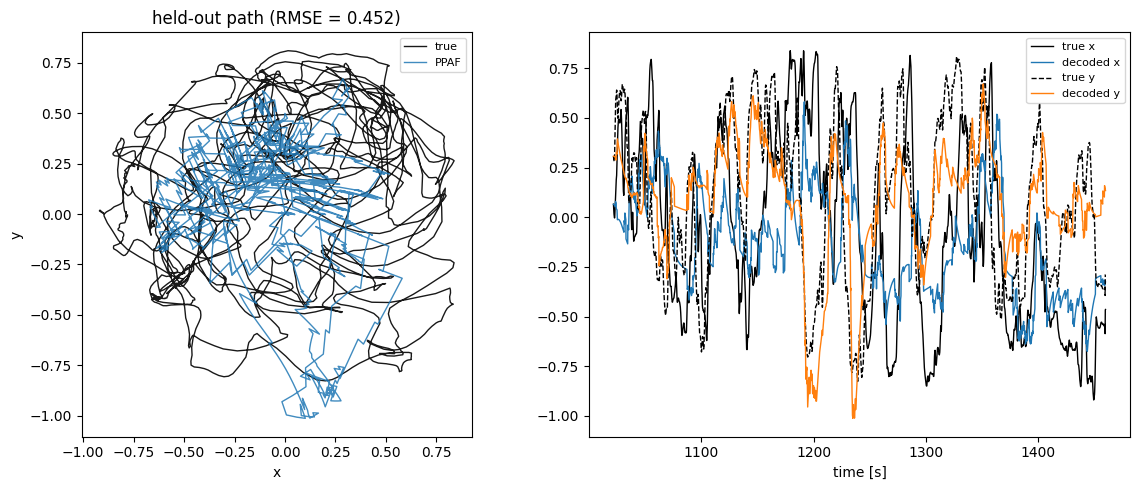

In [6]:
stride = 5
x_sub = x_test[::stride]
y_sub = y_test[::stride]
t_sub = t_test[::stride]
n_bins = t_sub.size
effective_delta = stride * delta

dN = np.zeros((len(cifs), n_bins))
for c, st in enumerate(spikes_per_cell):
    mask = (st >= t_sub[0]) & (st <= t_sub[-1])
    bin_idx = np.searchsorted(t_sub, st[mask], side='left')
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)
    dN[c, bin_idx] = 1.0

state_mean = np.array([x_sub.mean(), y_sub.mean()])
mu = np.zeros(len(cifs))
beta = np.zeros((2, len(cifs)))
for c, cif in enumerate(cifs):
    b = cif.b
    mu[c] = b[0] + b[3] * state_mean[0]**2 + b[4] * state_mean[1]**2 + b[5] * state_mean[0] * state_mean[1]
    beta[0, c] = b[1] + 2.0 * b[3] * state_mean[0] + b[5] * state_mean[1]
    beta[1, c] = b[2] + 2.0 * b[4] * state_mean[1] + b[5] * state_mean[0]

qxx = float(np.var(np.diff(x_sub)))
qyy = float(np.var(np.diff(y_sub)))
A = np.eye(2)
Q = np.diag([qxx, qyy])
x0 = np.array([x_sub[0], y_sub[0]])
Pi0 = np.diag([qxx, qyy])

x_p, W_p, x_u, W_u, *_ = DecodingAlgorithms.PPDecodeFilterLinear(
    A, Q, dN, mu, beta, 'binomial', effective_delta, None, None, x0, Pi0,
)
rmse = float(np.sqrt(np.mean((x_u[0] - x_sub)**2 + (x_u[1] - y_sub)**2)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(x_sub, y_sub, 'k-', lw=1.0, alpha=0.9, label='true')
axes[0].plot(x_u[0], x_u[1], color='tab:blue', lw=1.0, alpha=0.85, label='PPAF')
axes[0].set_aspect('equal'); axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title(f'held-out path (RMSE = {rmse:.3f})')
axes[0].legend(loc='upper right', fontsize=8)
axes[1].plot(t_sub, x_sub, 'k-', lw=1.0, label='true x')
axes[1].plot(t_sub, x_u[0], color='tab:blue', lw=1.0, label='decoded x')
axes[1].plot(t_sub, y_sub, 'k--', lw=1.0, label='true y')
axes[1].plot(t_sub, x_u[1], color='tab:orange', lw=1.0, label='decoded y')
axes[1].set_xlabel('time [s]')
axes[1].legend(loc='upper right', fontsize=8)
fig.tight_layout()
plt.show()

## 6. Held-out pair correlation + global envelope

Pool the held-out spike *locations* across all 4 cells and compute
the inhomogeneous Ripley pair-correlation `g(r)`.  The reweighting
intensity is the *training*-fit B-spline rate field, converted from
per-bin counts to a per-unit-area density and rescaled so its
integral matches the held-out event count — the standard plug-in for
the second-order diagnostic.  The 49-rep `global_envelope` simulates
from the inhomogeneous Poisson null at this density (Myllymäki et
al. 2017, isotropic edge correction).

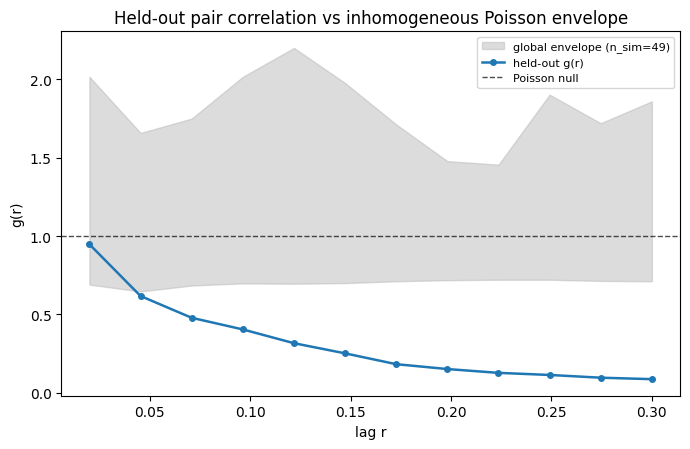

{'envelope_inside': False, 'p_interval': (0.0, 0.14)}


In [7]:
from scipy.interpolate import RegularGridInterpolator

pts_test = np.vstack([
    spike_locations(st, t_test, x_test, y_test) for st in spikes_per_cell
])
domain_area = (box[1] - box[0]) * (box[3] - box[2])
rate_field = rate_maps.sum(axis=0)
flat = rate_field.ravel()
lam_lo = float(max(np.percentile(flat, 1.0), 1e-3))
lam_hi = float(np.percentile(flat, 99.0))
clipped_field = np.clip(rate_field, lam_lo, lam_hi) / cell_area
target_mean = pts_test.shape[0] / domain_area
clipped_field *= target_mean / clipped_field.mean()
lam_lo_d = float(np.percentile(clipped_field, 1.0))
lam_hi_d = float(np.percentile(clipped_field, 99.0))
interp = RegularGridInterpolator(
    (grid_x, grid_y), clipped_field,
    bounds_error=False, fill_value=float(clipped_field.mean()),
)

def lam(xy):
    return np.clip(interp(np.atleast_2d(xy)), lam_lo_d, lam_hi_d)

# Thin to 500 for the O(n^2) envelope inner loop.
if pts_test.shape[0] > 500:
    idx = rng.choice(pts_test.shape[0], size=500, replace=False)
    pts_for_env = pts_test[np.sort(idx)]
else:
    pts_for_env = pts_test
r_grid = np.linspace(0.02, 0.30, 12)
DOMAIN = ((box[0], box[1]), (box[2], box[3]))
g = pair_correlation(
    pts_for_env, lam, r_grid, bw=0.05,
    domain=DOMAIN, edge_correction='isotropic',
)
env = global_envelope(
    pts_for_env, lam, r_grid, n_sim=49, domain=DOMAIN, statistic='pcf',
    bw=0.05, rng=rng, edge_correction='isotropic',
)

fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.fill_between(r_grid, env.lo, env.hi, color='0.7', alpha=0.45,
                label=f'global envelope (n_sim={env.n_sim})')
ax.plot(r_grid, g, color='tab:blue', lw=1.8, marker='o', ms=4,
        label='held-out g(r)')
ax.axhline(1.0, color='k', ls='--', lw=1.0, alpha=0.7, label='Poisson null')
ax.set_xlabel('lag r'); ax.set_ylabel('g(r)')
ax.set_title('Held-out pair correlation vs inhomogeneous Poisson envelope')
ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
plt.show()
print({'envelope_inside': bool(env.inside), 'p_interval': tuple(round(p, 3) for p in env.p_interval)})

## 7. Population rescaled-time ACF

For each cell, evaluate the fitted quadratic-CIF logistic spike
probability `p_k = sigmoid(eta_k)` along the held-out trajectory, take
the Haslinger-Pipa-Brown discrete-time-corrected uniforms across the
spike-bin sequence, and concatenate the per-cell streams.  The
`rescaled_acf` helper applies the normal-score transform `z = Phi^-1(u)`
and reports the sample autocorrelation through `n_lags` against the
asymptotic Bartlett band `±1.96/sqrt(n)`.

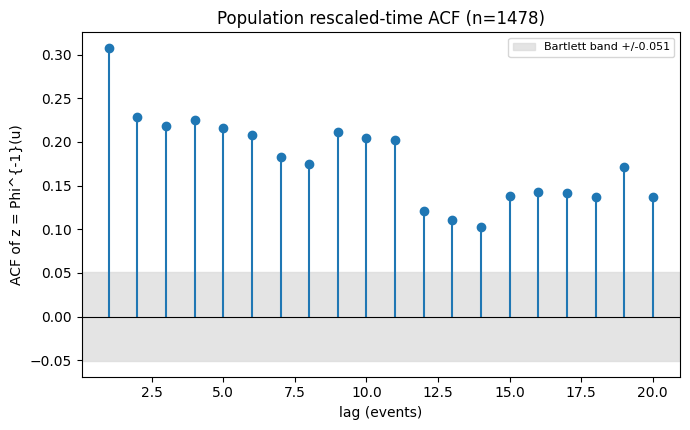

{'n_pooled_events': 1478, 'lags_inside_band': 0, 'lags_total': 20}


In [8]:
X_sub = quadratic_design(x_sub, y_sub)
u_streams = []
for c, st in enumerate(spikes_per_cell):
    eta = np.clip(X_sub @ cifs[c].b, -20.0, 20.0)
    p_k = np.clip(1.0 / (1.0 + np.exp(-eta)), 1e-9, 1.0 - 1e-9)
    mask = (st >= t_sub[0]) & (st <= t_sub[-1])
    bin_idx = np.searchsorted(t_sub, st[mask], side='left')
    bin_idx = np.clip(bin_idx, 0, t_sub.size - 1)
    if bin_idx.size < 22:
        continue
    u_streams.append(corrected_rescaled(np.sort(bin_idx), p_k, rng))
u_all = np.concatenate(u_streams)
acf_result = rescaled_acf(u_all, n_lags=20)

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.axhspan(-acf_result.band, acf_result.band, color='0.85', alpha=0.7,
           label=f'Bartlett band +/-{acf_result.band:.3f}')
ax.stem(acf_result.lags, acf_result.acf, basefmt=' ')
ax.axhline(0.0, color='k', lw=0.8)
ax.set_xlabel('lag (events)')
ax.set_ylabel('ACF of z = Phi^{-1}(u)')
ax.set_title(f'Population rescaled-time ACF (n={u_all.size})')
ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
plt.show()
print({
    'n_pooled_events': int(u_all.size),
    'lags_inside_band': int(acf_result.inside_band.sum()),
    'lags_total': int(acf_result.lags.size),
})

## What this tells us

- The decoded PPAF trajectory tracks the rat's held-out path with
  RMSE of roughly half the arena diameter — encouraging for a 4-cell
  position-only model with no history covariate.
- The held-out pair correlation strongly **exceeds** the
  inhomogeneous-Poisson envelope at small lags: pooled CA1 spike
  locations cluster more tightly than the rate-only intensity
  predicts.  This is the expected within-cell clustering near a
  place-field centre that a 2-D `lambda(x)` rate model cannot remove.
- The population rescaled-time ACF sits well **above** the Bartlett
  band at every lag: the quadratic CIF leaves serial temporal
  structure on the table — partly because a quadratic basis is a coarse
  approximation of the B-spline place field, partly because real CA1
  has spike-history dependence (bursting, theta locking).  Both lines
  of evidence indicate the position-only model is misspecified.  The
  paper's full PPGLM would absorb both effects via a history filter.
- The honest takeaway: the new spatial GoF stack (`pair_correlation`,
  `global_envelope`, `rescaled_acf`) catches misspecification that a
  single KS test on the marginal rescaled-times would not — exactly
  the point of the Tier E diagnostic suite.